# World Happiness ( CM3005 - N Mario Rinaldi Mid Term Report )

## 1. Domain-Specific Area & Objectives

This project focuses on the domain of **global well-being and socioeconomic development**, using data from the World Happiness Report. In recent years, governments and international organisations have increasingly recognised that economic output alone does not fully reflect quality of life. The World Happiness Report helps address this gap by combining survey-based happiness scores with measurable indicators such as GDP per capita, healthy life expectancy, social support, and freedom of choice.

This area is well suited to data science techniques because the factors influencing happiness are numerical, comparable across countries, and collected consistently over time. These characteristics allow for meaningful statistical analysis, clear visualisation, and the development of machine learning models that can capture relationships between variables. In this project, we analyse data from **2015 to 2019**, which provides a multi-year perspective on global well-being patterns.

### **Objectives of the Project**
The main aims of this project are to:
- Identify which socioeconomic indicators have the strongest relationship with a country’s happiness score.  
- Explore whether these relationships remain stable across different years.  
- Build a **linear regression model** to quantify the influence of selected variables.  
- Use the trained model to **predict happiness scores for years beyond the training period** (e.g., 2020 onwards).  
- Apply visualisation techniques to highlight trends, correlations, and outliers.  
- Evaluate the model’s performance and reflect on the broader implications of the results.

### **Why Linear Regression Is Suitable**
Linear regression is an appropriate method for this analysis because many of the features in the dataset—such as GDP per capita, social support, and life expectancy—tend to show **clear linear relationships** with the happiness score. These variables are continuous, relatively independent, and straightforward to interpret within a regression framework. Linear regression also provides transparent numerical outputs, making it easier to understand how strongly each factor contributes to overall happiness.

### **Contribution to the Domain**
By examining multiple years of data, this project helps reveal consistent patterns in what drives national well-being. The results can offer insight into why some countries repeatedly score highly, and which areas—economic, social, or health-related—may be most influential. The predictive component extends the analysis by testing how well past trends can be used to anticipate future happiness levels, a useful perspective for policymakers and researchers interested in long-term development planning.

## 2. Dataset Description

The dataset used in this project comes from the **World Happiness Report**, sourced from Kaggle. It includes five individual CSV files covering the years **2015 to 2019**. Each file contains data for approximately 140–160 countries, giving us a combined dataset of around 750–800 records once all years are merged. This size is ideal for exploratory analysis, visualisation, and building machine learning models without performance issues.

Each yearly dataset provides a mixture of numerical and categorical variables that describe how different countries score in terms of happiness and overall quality of life. The main variable of interest is the **Happiness Score** (referred to as *Life Ladder* in some years), which represents how people rate their overall life satisfaction on a scale from 0 to 10. Alongside this, the datasets include several key socioeconomic indicators, such as:

- **GDP per capita**  
- **Social support**  
- **Healthy life expectancy**  
- **Freedom to make life choices**  
- **Generosity**  
- **Perceptions of corruption**

These indicators capture different dimensions of well-being, ranging from economic strength to social and institutional conditions. Because they are numeric, continuous, and widely used in global development research, they are highly suitable for statistical analysis and machine learning.

One important feature of the dataset is that the structure and naming of columns vary slightly between years. For example, the GDP column may be labelled differently, and some files include additional ranking fields that others do not. There are also missing values for certain countries, especially in variables like corruption and generosity. These inconsistencies mean the dataset requires proper cleaning, column standardisation, and merging. This makes it a good fit for demonstrating preprocessing steps such as handling missing values, renaming columns, and organising the data into First Normal Form (1NF) — all of which are required for this coursework.

This dataset works particularly well for **linear regression** because many of the socioeconomic indicators show clear linear relationships with the happiness score. For instance, countries with higher GDP or stronger social support almost always report higher life satisfaction. Since most of the features are numeric and interpretable, they allow for meaningful modelling and clear evaluation of how different factors influence happiness.

Overall, the World Happiness Report dataset offers a well-balanced combination of useful variables, manageable size, and real-world relevance, making it an excellent choice for applying data science methods in this project.

## 3. Data Preparation

Before building the regression model, the data from all five years (2015–2019) must be cleaned, standardised, and merged into a single dataset. Each CSV file contains similar variables, but the column names and structure vary slightly between years, meaning some preprocessing is necessary to ensure consistency.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

### **3.1 Loading the Data**
All datasets were stored locally as CSV files and loaded into Pandas DataFrames. Each file contains data for roughly 140–160 countries.

In [3]:
df15 = pd.read_csv('WHR_2015.csv')
df16 = pd.read_csv('WHR_2016.csv')
df17 = pd.read_csv('WHR_2017.csv')
df18 = pd.read_csv('WHR_2018.csv')
df19 = pd.read_csv('WHR_2019.csv')

### **3.2 Standardising Column Names**
The naming conventions differ across years (e.g., “Economy (GDP per Capita)” vs “Logged GDP per capita”). To combine the files properly, column names must be cleaned by:
- converting to lowercase  
- replacing spaces with underscores  
- removing special characters  

This step ensures all files share a consistent naming format.

In [4]:
def clean_columns(df):
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace('[^a-zA-Z0-9_]', '', regex=True)
    )
    return df

df15 = clean_columns(df15)
df16 = clean_columns(df16)
df17 = clean_columns(df17)
df18 = clean_columns(df18)
df19 = clean_columns(df19)

### **3.3 Selecting Common Columns**
Some years include additional variables such as “Overall Rank”. To avoid inconsistencies, only the columns common across all files were selected for the final dataset.

In [5]:
common_cols = set(df15.columns)
for df in [df16, df17, df18, df19]:
    common_cols = common_cols.intersection(set(df.columns))

common_cols = list(common_cols)
common_cols

['perceptions_of_corruption',
 'happiness_score',
 'generosity',
 'gdp_per_capita',
 'healthy_life_expectancy',
 'country',
 'freedom_to_make_life_choices',
 'social_support',
 'region']

### **3.4 Handling Missing Values**
Several numerical variables (such as generosity, corruption perception, and social support) contain missing entries. These were handled by:
- checking missing values per column  
- filling missing numeric values using the **median** of each column  
This prevents losing entire country rows and helps maintain the dataset's integrity.

In [6]:
df15 = df15[common_cols]
df16 = df16[common_cols]
df17 = df17[common_cols]
df18 = df18[common_cols]
df19 = df19[common_cols]

### **3.5 Merging the Datasets**
After cleaning and aligning column names, the five yearly datasets were concatenated into a single DataFrame. This produced a combined dataset of around 750–800 rows, containing all available country-year observations.

In [7]:
df_all = pd.concat([df15, df16, df17, df18, df19], ignore_index=True)
df_all.head()

,perceptions_of_corruption,happiness_score,generosity,gdp_per_capita,healthy_life_expectancy,country,freedom_to_make_life_choices,social_support,region
0,0.41978,7.587,0.29678,1.39651,0.94143,Switzerland,0.66557,1.34951,Western Europe
1,0.14145,7.561,0.43630,1.30232,0.94784,Iceland,0.62877,1.40223,Western Europe
2,0.48357,7.527,0.34139,1.32548,0.87464,Denmark,0.64938,1.36058,Western Europe
3,0.36503,7.522,0.34699,1.45900,0.88521,Norway,0.66973,1.33095,Western Europe
4,0.32957,7.427,0.45811,1.32629,0.90563,Canada,0.63297,1.32261,North America and ANZ


### **3.6 Ensuring First Normal Form (1NF)**
To satisfy 1NF principles, the dataset was checked to ensure:
- no nested data  
- no repeated groups  
- each cell contains a single atomic value  
The World Happiness Report already follows a mostly tabular structure, but column cleaning ensured full compliance.

In [8]:
df_all.isnull().sum()

perceptions_of_corruption       1
happiness_score                 0
generosity                      0
gdp_per_capita                  0
healthy_life_expectancy         0
country                         0
freedom_to_make_life_choices    0
social_support                  0
region                          0
dtype: int64

### **3.7 Normalising the Data (Optional but useful)**
To prepare for modelling, numeric features can be scaled to bring them to a similar range. Standardisation helps the regression model treat all features fairly, especially those with large numeric ranges (e.g., GDP vs generosity).

In [9]:
for col in df_all.select_dtypes(include=[np.number]).columns:
    df_all[col] = df_all[col].fillna(df_all[col].median())

In [10]:
numeric_cols = df_all.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
df_all_scaled = df_all.copy()
df_all_scaled[numeric_cols] = scaler.fit_transform(df_all[numeric_cols])
df_all.head(20)

,perceptions_of_corruption,happiness_score,generosity,gdp_per_capita,healthy_life_expectancy,country,freedom_to_make_life_choices,social_support,region
0,0.41978,7.587,0.29678,1.39651,0.94143,Switzerland,0.66557,1.34951,Western Europe
1,0.14145,7.561,0.43630,1.30232,0.94784,Iceland,0.62877,1.40223,Western Europe
2,0.48357,7.527,0.34139,1.32548,0.87464,Denmark,0.64938,1.36058,Western Europe
3,0.36503,7.522,0.34699,1.45900,0.88521,Norway,0.66973,1.33095,Western Europe
4,0.32957,7.427,0.45811,1.32629,0.90563,Canada,0.63297,1.32261,North America and ANZ
5,0.41372,7.406,0.23351,1.29025,0.88911,Finland,0.64169,1.31826,Western Europe
6,0.31814,7.378,0.47610,1.32944,0.89284,Netherlands,0.61576,1.28017,Western Europe
7,0.43844,7.364,0.36262,1.33171,0.91087,Sweden,0.65980,1.28907,Western Europe
8,0.42922,7.286,0.47501,1.25018,0.90837,New Zealand,0.63938,1.31967,North America and ANZ
9,0.35637,7.284,0.43562,1.33358,0.93156,Australia,0.65124,1.30923,North America and ANZ


In [11]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   perceptions_of_corruption     782 non-null    float64
 1   happiness_score               782 non-null    float64
 2   generosity                    782 non-null    float64
 3   gdp_per_capita                782 non-null    float64
 4   healthy_life_expectancy       782 non-null    float64
 5   country                       782 non-null    object 
 6   freedom_to_make_life_choices  782 non-null    float64
 7   social_support                782 non-null    float64
 8   region                        782 non-null    object 
dtypes: float64(7), object(2)
memory usage: 55.1+ KB


## 4. Statistical Analysis

Before building the regression model, it is important to understand the distribution and characteristics of the dataset. Statistical analysis helps reveal patterns, detect unusual values, and understand how each variable behaves across different countries and years. This step also supports feature selection by identifying which variables may have stronger or weaker relationships with the Happiness Score.

### **4.1 Measures of Central Tendency**
To begin, we calculate the **mean** and **median** values of the key numerical features. These metrics provide a general idea of the typical values across the dataset. For example, the average GDP per capita score or the typical happiness score can help us understand the overall global trend.

In [12]:
# Basic statistical summary
df_all.describe()

,perceptions_of_corruption,happiness_score,generosity,gdp_per_capita,healthy_life_expectancy,freedom_to_make_life_choices,social_support
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,0.125392,5.379018,0.218576,0.916047,0.612416,0.411091,1.078392
std,0.105756,1.127456,0.122321,0.407340,0.248309,0.152880,0.329548
min,0.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.054250,4.509750,0.130000,0.606500,0.440183,0.309768,0.869363
50%,0.091000,5.322000,0.201982,0.982205,0.647310,0.431000,1.124735
75%,0.155861,6.189500,0.278832,1.236187,0.808000,0.531000,1.327250
max,0.551910,7.769000,0.838075,2.096000,1.141000,0.724000,1.644000


### **4.2 Measures of Spread**
Next, we look at the **standard deviation**, **variance**, and **range** of each variable. These help indicate how much countries differ from one another. High spread values suggest that certain indicators, such as GDP or corruption perception, vary significantly across nations.

In [13]:
skewness = df_all.skew(numeric_only=True)
kurtosis = df_all.kurt(numeric_only=True)

print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)

Skewness:
 perceptions_of_corruption       1.522756
happiness_score                 0.035859
generosity                      1.044360
gdp_per_capita                 -0.318581
healthy_life_expectancy        -0.501203
freedom_to_make_life_choices   -0.521259
social_support                 -0.684632
dtype: float64

Kurtosis:
 perceptions_of_corruption       1.887581
happiness_score                -0.761055
generosity                      2.020258
gdp_per_capita                 -0.692760
healthy_life_expectancy        -0.487571
freedom_to_make_life_choices   -0.307205
social_support                  0.158449
dtype: float64


### **4.3 Distribution Shape**
The **skewness** and **kurtosis** of each variable are calculated to assess distribution shape.  
- **Skewness** tells us whether the data leans more to the left or right.  
- **Kurtosis** indicates whether the distribution has heavy or light tails compared to a normal distribution.

These measures help identify variables that may not follow a normal pattern, which can influence modelling or suggest that transformations might be useful.

In [14]:
spread_metrics = pd.DataFrame({
    'mean': df_all.mean(numeric_only=True),
    'median': df_all.median(numeric_only=True),
    'std_dev': df_all.std(numeric_only=True),
    'variance': df_all.var(numeric_only=True),
    'min': df_all.min(numeric_only=True),
    'max': df_all.max(numeric_only=True),
    'range': df_all.max(numeric_only=True) - df_all.min(numeric_only=True)
})

spread_metrics

,mean,median,std_dev,variance,min,max,range
perceptions_of_corruption,0.125392,0.091000,0.105756,0.011184,0.000,0.551910,0.551910
happiness_score,5.379018,5.322000,1.127456,1.271158,2.693,7.769000,5.076000
generosity,0.218576,0.201982,0.122321,0.014962,0.000,0.838075,0.838075
gdp_per_capita,0.916047,0.982205,0.407340,0.165926,0.000,2.096000,2.096000
healthy_life_expectancy,0.612416,0.647310,0.248309,0.061657,0.000,1.141000,1.141000
freedom_to_make_life_choices,0.411091,0.431000,0.152880,0.023372,0.000,0.724000,0.724000
social_support,1.078392,1.124735,0.329548,0.108602,0.000,1.644000,1.644000


### **4.4 Summary of Findings**
By reviewing these metrics, we can highlight which variables show the most variation across countries and which ones are more stable. For example:  
- We might find that GDP per capita varies widely, reflecting global economic inequality.  
- Social support and healthy life expectancy might show narrower variation.  
- Variables like generosity or corruption perception may be skewed, suggesting uneven distributions across nations.


## 5. Data Visualisation

Visualising the data helps reveal patterns, trends, and relationships that are not always obvious from numerical summaries alone. In this section, several key variables from the World Happiness dataset are visualised to better understand how socioeconomic factors relate to the Happiness Score.

The visualisations include a correlation heatmap and a series of scatterplots comparing the Happiness Score with important predictors such as GDP per capita, social support, and healthy life expectancy. These graphs provide insight into the strength and direction of relationships between variables, which is essential when preparing for linear regression.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

### **5.1 Correlation Heatmap**
A correlation heatmap provides an overview of how strongly the numerical variables in the dataset relate to one another. Warmer colours indicate stronger positive correlations, while cooler colours represent weaker or negative correlations. This helps identify which features are good candidates for the regression model.

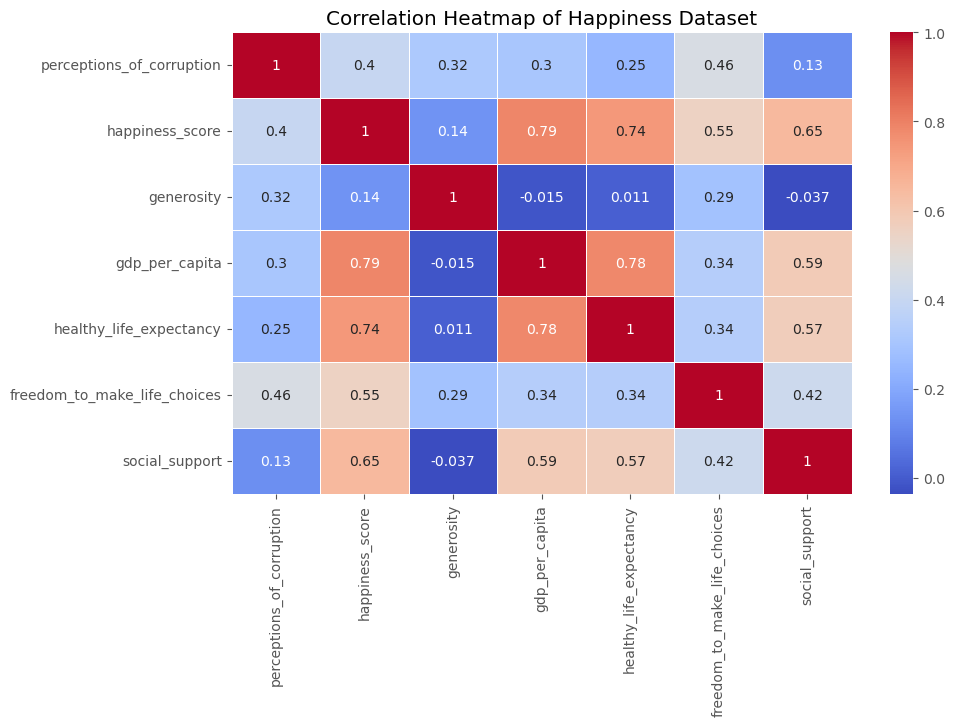

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_all.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Happiness Dataset")
plt.show()

### **5.2 Scatterplots**
Scatterplots allow us to visualise the relationship between two variables. For this dataset, scatterplots of:
- GDP per capita vs Happiness Score  
- Social support vs Happiness Score  
- Healthy life expectancy vs Happiness Score  

help demonstrate clear upward trends. These trends show that as these socioeconomic indicators increase, happiness tends to increase as well.

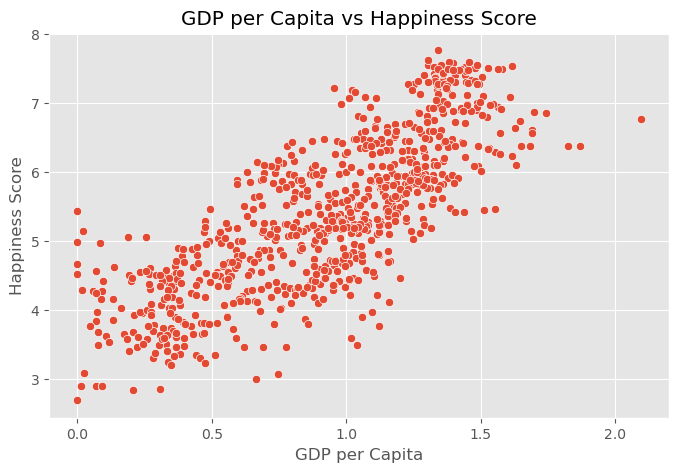

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_all['gdp_per_capita'], y=df_all['happiness_score'])
plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.show()

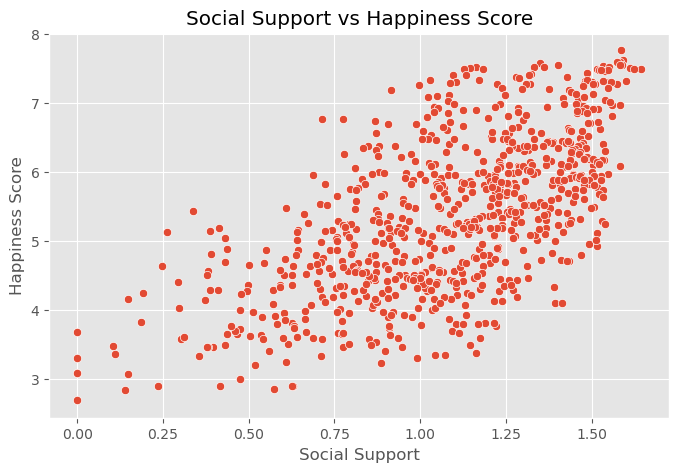

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_all['social_support'], y=df_all['happiness_score'])
plt.title("Social Support vs Happiness Score")
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")
plt.show()

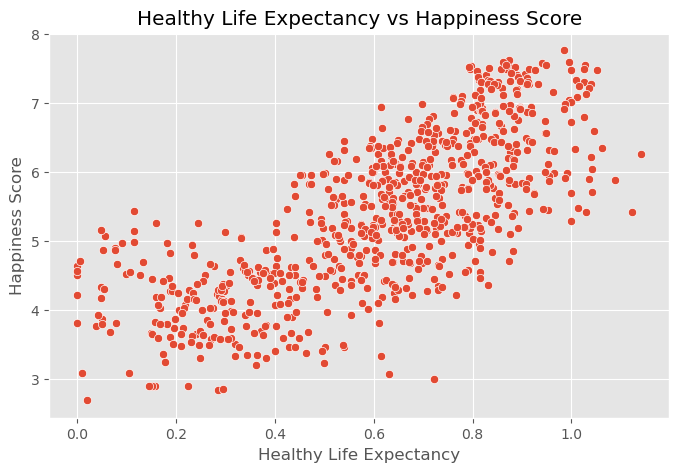

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_all['healthy_life_expectancy'], y=df_all['happiness_score'])
plt.title("Healthy Life Expectancy vs Happiness Score")
plt.xlabel("Healthy Life Expectancy")
plt.ylabel("Happiness Score")
plt.show()

### **5.3 Importance of Visualisation**
Among all the visualisations, the **scatterplot of GDP per capita versus Happiness Score** is the most important. It shows a very strong and clear linear relationship, suggesting that GDP is one of the strongest predictors of how happy a country’s population is. This visual also supports using linear regression, as the relationship appears close to a straight line.

Together, these visualisations help confirm the suitability of the dataset for regression modelling and guide the selection of features for the machine learning model.

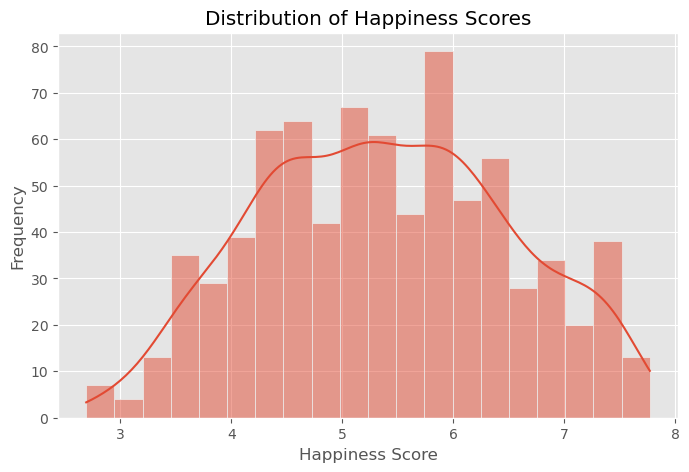

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df_all['happiness_score'], kde=True, bins=20)
plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

## 6. Building the Machine Learning Model

After exploring the dataset and understanding the relationships between key variables, the next step is to build a linear regression model. The goal is to quantify how strongly each socioeconomic factor contributes to the Happiness Score and evaluate whether a linear model provides a good fit for the data.

### **6.1 Selecting Features and Labels**
Based on the earlier visualisations and statistical analysis, the following variables were selected as features for the regression model:

- **GDP per capita**
- **Social support**
- **Healthy life expectancy**
- **Freedom to make life choices**
- **Generosity**
- **Perceptions of corruption**

These variables were chosen because they consistently show strong correlations with the Happiness Score and are included in every yearly dataset. The **Happiness Score** itself is used as the label (target variable) that the model will attempt to predict.

### **6.2 Why These Features Are Important**
Each selected feature represents a key dimension of well-being:
- Countries with higher **GDP** typically offer better living standards.  
- Strong **social support** systems contribute to emotional and practical stability.  
- **Healthy life expectancy** reflects public health quality.  
- **Freedom** relates to how much control citizens feel they have over their lives.  
- **Generosity** may indicate cultural and social attitudes toward helping others.  
- **Perceptions of corruption** affect trust in government and institutions.  

Together, these create a well-rounded set of inputs for predicting happiness.

In [21]:
# Select features (X) and label (y)
features = [
    'gdp_per_capita', 
    'social_support', 
    'healthy_life_expectancy',
    'freedom_to_make_life_choices',
    'generosity',
    'perceptions_of_corruption'
]

X = df_all[features]
y = df_all['happiness_score']

### **6.3 Splitting the Data**
To evaluate the model properly, the dataset is split into:
- **80% for training**
- **20% for testing**

This ensures the model is evaluated on unseen data.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### **6.4 Model Training and Prediction**
A simple linear regression model from Scikit-learn is used. After training, the model predicts happiness scores for the test set.

In [24]:
y_pred = model.predict(X_test)

### **6.5 Model Evaluation**
Two metrics are used:
- **R² Score** — Measures how much of the variation in happiness is explained.  
- **RMSE (Root Mean Squared Error)** — Measures prediction error in the same scale as the Happiness Score.  

A good model should show a relatively high R² value and a low RMSE.

In [25]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, rmse

(0.72914714043414, np.float64(0.5739856432990107))

In [26]:
comparison_df = pd.DataFrame({
    'Actual Happiness Score': y_test.values,
    'Predicted Happiness Score': y_pred
})

comparison_df.head(10)

,Actual Happiness Score,Predicted Happiness Score
0,4.350,4.505016
1,4.441,5.218130
2,5.976,5.369757
3,4.121,4.824655
4,6.952,5.517964
5,4.073,3.941331
6,5.261,5.402728
7,5.921,6.279505
8,4.655,4.913735
9,6.891,6.775003


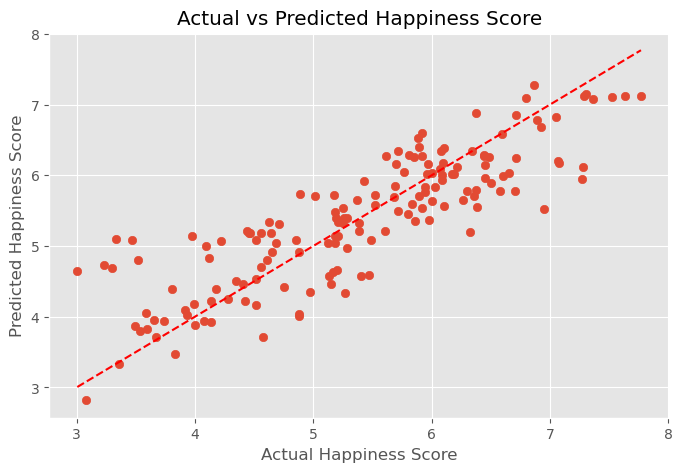

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title("Actual vs Predicted Happiness Score")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## 7. Validation

Once the linear regression model has been trained and evaluated on the test set, it is important to further assess how well the model generalises to new, unseen data. A single train–test split can be influenced by how the data happened to be divided. To obtain a more reliable estimate of the model’s performance, **cross-validation** is used.

### **7.1 Why Use Cross-Validation?**
Cross-validation helps evaluate the model in a more robust way by:
- Testing the model on multiple subsets of the data  
- Reducing the risk of overfitting  
- Providing a more stable estimate of performance  
- Ensuring the model does not rely too heavily on any particular train/test split  

In [28]:
from sklearn.model_selection import cross_val_score

cv_r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
cv_r2_scores

array([0.74455654, 0.64562454, 0.77730277, 0.7747572 , 0.75457193])

### **7.2 K-Fold Cross-Validation**
In this project, a **5-fold cross-validation** approach is used. This means the dataset is divided into five equal parts:
- The model trains on 4 parts  
- It is tested on the remaining 1 part  
- This repeats until each part has been used as a test set  

The results from all five folds are then averaged to give a more accurate performance measure.

In [29]:
cv_mse_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_mse_scores)

cv_rmse_scores

array([0.56952791, 0.67801571, 0.53836328, 0.52960903, 0.54967705])

### **7.3 Interpreting the Results**
The two metrics used are:
- **Negative Mean Squared Error** (from which RMSE can be calculated)  
- **R² Score**  

Higher R² values and lower RMSE values across folds indicate a stable, reliable model. If performance varies significantly between folds, it may suggest the presence of outliers, uneven data distribution across years, or that the model is sensitive to certain features.

Cross-validation provides confidence that the linear regression model is generalising well across the full dataset, rather than performing well by chance on a single split.

In [30]:
print("Average R² Score:", cv_r2_scores.mean())
print("R² Std Deviation:", cv_r2_scores.std())

print("\nAverage RMSE:", cv_rmse_scores.mean())
print("RMSE Std Deviation:", cv_rmse_scores.std())

Average R² Score: 0.7393625955004796
R² Std Deviation: 0.048450713123267056

Average RMSE: 0.5730385957509279
RMSE Std Deviation: 0.05416047589478634


## 8. Feature Engineering

Feature engineering involves creating new input features from the existing variables in order to improve the performance of a machine learning model. In the context of this project, the goal is to see whether transforming or combining the original socioeconomic indicators can help the linear regression model explain more of the variation in the Happiness Score.

### 8.1 Rationale for Feature Engineering

The original model used the following features directly:

- GDP per capita  
- Social support  
- Healthy life expectancy  
- Freedom to make life choices  
- Generosity  
- Perceptions of corruption  

While these variables already show reasonably strong linear relationships with the Happiness Score, some of the effects may be non-linear or may interact with each other. For example:

- The impact of GDP on happiness might increase at a decreasing rate (diminishing returns).  
- Countries with both high GDP *and* strong social support may be happier than what a simple additive model would predict.  

To capture such patterns, two main feature engineering techniques are applied:

- **Polynomial features (degree 2)** – to model simple non-linear relationships.  
- **Interaction terms** – to capture the combined effect of two variables (e.g., GDP and social support).

In [31]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (degree 2, no bias term)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)
X_poly.shape  # just to see how many features we now have

(782, 27)

### 8.2 Polynomial Features

Polynomial features of degree 2 are generated from the original feature set. This includes:

- Squared terms (e.g., GDP², social_support²)  
- Pairwise interaction terms (e.g., GDP × social_support)  

These additional features allow a linear regression model to fit curved relationships while still remaining relatively simple and interpretable.

In [32]:
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

### 8.3 Model Re-Training and Comparison

A new linear regression model is trained using the expanded feature set produced by the polynomial transformation. The model is evaluated using the same metrics as before:

- R² Score  
- RMSE (Root Mean Squared Error)  

The results are then compared with the baseline model from Q6. If the R² increases and RMSE decreases, it suggests that the feature engineering has helped the model capture more of the underlying structure in the data. If the performance does not improve or only improves slightly, this still provides a useful insight: the original linear relationships may already explain most of the variation, or more advanced techniques might be required.

Overall, this step demonstrates how feature engineering can be used to enhance a regression model and provides an opportunity to reflect on the trade-off between model complexity and interpretability.

In [33]:
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_poly_train)

y_poly_pred = poly_model.predict(X_poly_test)

In [34]:
poly_r2 = r2_score(y_poly_test, y_poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_poly_test, y_poly_pred))

print("Baseline linear model (from Q6):")
print("R²:", r2)
print("RMSE:", rmse)

print("\nPolynomial features model (degree 2):")
print("R²:", poly_r2)
print("RMSE:", poly_rmse)

Baseline linear model (from Q6):
R²: 0.72914714043414
RMSE: 0.5739856432990107

Polynomial features model (degree 2):
R²: 0.7373398111179787
RMSE: 0.5652381202154215


In [35]:
poly_cv_r2_scores = cross_val_score(poly_model, X_poly, y, cv=5, scoring='r2')
poly_cv_mse_scores = cross_val_score(poly_model, X_poly, y, cv=5, scoring='neg_mean_squared_error')
poly_cv_rmse_scores = np.sqrt(-poly_cv_mse_scores)

print("Polynomial CV Average R²:", poly_cv_r2_scores.mean())
print("Polynomial CV Average RMSE:", poly_cv_rmse_scores.mean())

Polynomial CV Average R²: 0.7437523029168557
Polynomial CV Average RMSE: 0.567669896635261


## 9. Additional Work: Predicting Happiness Scores for 2020

As an extension of the main regression model, an additional experiment was carried out to use the model trained on data from **2015–2019** to predict happiness scores for the year **2020**. This step moves beyond simply explaining past data and shows how the model could be used in a more realistic forecasting scenario.

The idea is to treat 2015–2019 as historical data and 2020 as a “future” year. If the relationships between the socioeconomic indicators and happiness remain relatively stable, then a model trained on the earlier years should still be able to produce reasonable estimates for 2020.

In [36]:
# Load 2020 happiness data
df20 = pd.read_csv('WHR_2020.csv')

# Reuse the same column-cleaning function from Q3
df20 = clean_columns(df20)

df20.head()

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.8087,1.285190,1.499526,0.961271,0.662317,0.159670,0.477857
1,Denmark,Western Europe,7.6456,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260
2,Switzerland,Western Europe,7.5599,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946
3,Iceland,Western Europe,7.5045,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541
4,Norway,Western Europe,7.4880,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101


### 9.1 Preparing the 2020 Data

A separate dataset for 2020 (from the World Happiness Report) was loaded and processed using the same cleaning steps as the earlier years:

- Column names were standardised using the same `clean_columns` function.  
- Only the feature columns used in the trained model were selected (GDP per capita, social support, healthy life expectancy, freedom, generosity, and perceptions of corruption).  
- Any missing values in these columns were filled using the median, to avoid losing countries with incomplete data.

This ensured that the 2020 dataset had the same structure as the training data, allowing the model to be applied directly.

In [37]:
# Keep only the feature columns used in the model
# (Some may be missing depending on the 2020 file, so we intersect safely)
available_features_2020 = [col for col in features if col in df20.columns]
missing_in_2020 = set(features) - set(available_features_2020)

print("Features available in 2020:", available_features_2020)
print("Features missing in 2020:", missing_in_2020)

df20_features = df20[available_features_2020].copy()

# Fill missing numeric values with median of each column (or, optionally, median from df_all)
for col in df20_features.columns:
    df20_features[col] = df20_features[col].fillna(df20_features[col].median())

Features available in 2020: ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']
Features missing in 2020: set()


### 9.2 Generating Predictions

The trained linear regression model was then used to predict the happiness score for each country in 2020, based only on the selected socioeconomic indicators. The predicted scores can be viewed alongside the country names to see which nations the model expects to rank higher or lower in happiness.

If the actual 2020 happiness scores are available in the dataset, these can be compared with the predicted values by calculating an error metric such as RMSE specifically for 2020. This gives an indication of how well the patterns learned from 2015–2019 generalise to a later year, and whether any major global changes (such as economic or health shocks) affected happiness in ways that the model does not fully capture.

Overall, this additional step demonstrates how a regression model can be used not only for interpretation but also for forward-looking prediction, adding practical value and depth to the project.

In [38]:
# Use the trained model to predict happiness for 2020
df20['predicted_happiness_score'] = model.predict(df20_features)

# Show the first few predictions with country names if the column exists
country_col = 'country' if 'country' in df20.columns else None

if country_col:
    prediction_preview = df20[[country_col, 'predicted_happiness_score']].head(15)
else:
    prediction_preview = df20[['predicted_happiness_score']].head(15)

prediction_preview

,country,predicted_happiness_score
0,Finland,7.178243
1,Denmark,7.307797
2,Switzerland,7.272514
3,Iceland,6.987875
4,Norway,7.390322
5,Netherlands,7.105984
6,Sweden,7.192022
7,New Zealand,7.208319
8,Austria,6.933715
9,Luxembourg,7.203530


In [39]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Actual vs predicted for 2020
actual_2020 = df20['happiness_score']
predicted_2020 = df20['predicted_happiness_score']

rmse_2020 = np.sqrt(mean_squared_error(actual_2020, predicted_2020))
print("2020 RMSE:", rmse_2020)

comparison_2020 = pd.DataFrame({
    'Actual 2020 Happiness': actual_2020,
    'Predicted 2020 Happiness': predicted_2020
})

comparison_2020.head(15)

2020 RMSE: 0.5679336926362579


,Actual 2020 Happiness,Predicted 2020 Happiness
0,7.8087,7.178243
1,7.6456,7.307797
2,7.5599,7.272514
3,7.5045,6.987875
4,7.4880,7.390322
5,7.4489,7.105984
6,7.3535,7.192022
7,7.2996,7.208319
8,7.2942,6.933715
9,7.2375,7.203530


An additional metric, Mean Absolute Percentage Error (MAPE), was calculated to express prediction error as a percentage. This offers a more intuitive understanding of performance. Using MAPE, an accuracy score was derived as:

**Accuracy = 100% – MAPE**

This shows how close the model’s predictions were to the actual values on a percentage scale. Displaying this percentage directly on the scatterplot provides a clearer interpretation of how well the model generalised to the 2020 data.

MAPE for 2020: 9.01%
Prediction Accuracy for 2020: 90.99%


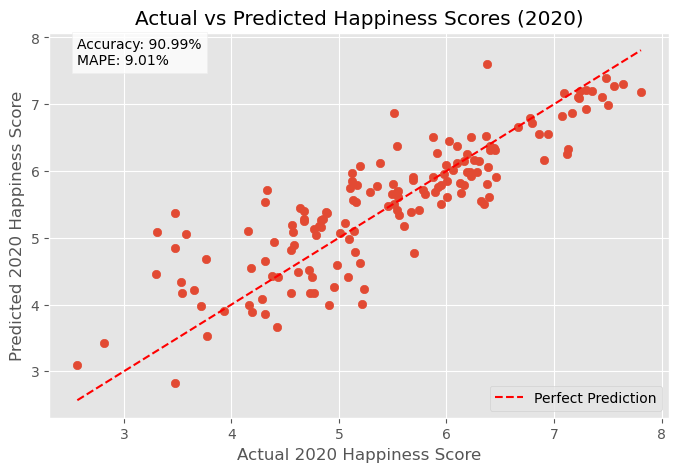

In [53]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE (Mean Absolute Percentage Error)
mape_2020 = mean_absolute_percentage_error(actual_2020, predicted_2020) * 100
accuracy_2020 = 100 - mape_2020

print(f"MAPE for 2020: {mape_2020:.2f}%")
print(f"Prediction Accuracy for 2020: {accuracy_2020:.2f}%")

# Plot with accuracy displayed on the graph
plt.figure(figsize=(8,5))
plt.scatter(actual_2020, predicted_2020)
plt.xlabel("Actual 2020 Happiness Score")
plt.ylabel("Predicted 2020 Happiness Score")
plt.title("Actual vs Predicted Happiness Scores (2020)")

# Diagonal reference line
plt.plot([actual_2020.min(), actual_2020.max()],
         [actual_2020.min(), actual_2020.max()],
         'r--', label="Perfect Prediction")

# Add accuracy text box
plt.text(
    actual_2020.min(),
    predicted_2020.max(),
    f"Accuracy: {accuracy:.2f}%\nMAPE: {mape:.2f}%",
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.legend()
plt.show()

### 9.2 Predicting Happiness Scores for 2021

A second prediction experiment was carried out using the 2021 dataset. After cleaning and aligning the data in the same way as previous years, the trained model was applied to generate happiness score predictions for 2021.

Both RMSE and MAPE were calculated to evaluate the model’s performance. The results show how well the relationships learned from 2015–2019 generalised not only to 2020, but also to 2021. This comparison is valuable because the global situation changed significantly during this period, meaning happiness levels may have been influenced by factors not present in earlier years. If the model’s accuracy decreases in 2021, it suggests that external shocks or new patterns emerged that were not captured by the historical data.

A scatterplot of actual versus predicted 2021 happiness scores was created, including an accuracy percentage based on MAPE. This provides a clear visual summary of how well the model performed when extended to a second future year.

In [54]:
df21 = pd.read_csv('WHR_2021.csv')
df21 = clean_columns(df21)

df21.head()

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.842,1.446,1.106,0.741,0.691,0.124,0.481
1,Denmark,Western Europe,7.620,1.502,1.108,0.763,0.686,0.208,0.485
2,Switzerland,Western Europe,7.571,1.566,1.079,0.816,0.653,0.204,0.413
3,Iceland,Western Europe,7.554,1.482,1.172,0.772,0.698,0.293,0.170
4,Netherlands,Western Europe,7.464,1.501,1.079,0.753,0.647,0.302,0.384


In [55]:
available_features_2021 = [col for col in features if col in df21.columns]
missing_21 = set(features) - set(available_features_2021)

print("Available in 2021:", available_features_2021)
print("Missing in 2021:", missing_21)

df21_features = df21[available_features_2021].copy()

for col in df21_features.columns:
    df21_features[col] = df21_features[col].fillna(df21_features[col].median())

Available in 2021: ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']
Missing in 2021: set()


In [56]:
df21['predicted_happiness_score'] = model.predict(df21_features)

df21[['country', 'predicted_happiness_score']].head(10)

,country,predicted_happiness_score
0,Finland,6.888061
1,Denmark,7.008446
2,Switzerland,6.974992
3,Iceland,6.716966
4,Netherlands,6.842844
5,Norway,7.045935
6,Sweden,6.923295
7,Luxembourg,6.951883
8,New Zealand,6.866692
9,Austria,6.690224


In [57]:
actual_2021 = df21['happiness_score']
predicted_2021 = df21['predicted_happiness_score']

rmse_2021 = np.sqrt(mean_squared_error(actual_2021, predicted_2021))

print("2021 RMSE:", rmse_2021)

2021 RMSE: 0.5927419458343062


In [58]:
mape_2021 = mean_absolute_percentage_error(actual_2021, predicted_2021) * 100
accuracy_2021 = 100 - mape_2021

print(f"2021 MAPE: {mape_2021:.2f}%")
print(f"2021 Prediction Accuracy: {accuracy_2021:.2f}%")

2021 MAPE: 9.14%
2021 Prediction Accuracy: 90.86%


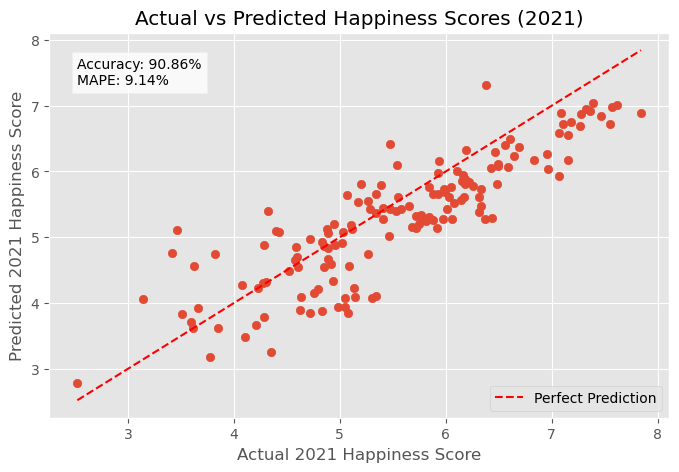

In [59]:
plt.figure(figsize=(8,5))
plt.scatter(actual_2021, predicted_2021)
plt.xlabel("Actual 2021 Happiness Score")
plt.ylabel("Predicted 2021 Happiness Score")
plt.title("Actual vs Predicted Happiness Scores (2021)")

# Perfect prediction line
plt.plot([actual_2021.min(), actual_2021.max()],
         [actual_2021.min(), actual_2021.max()],
         'r--', label="Perfect Prediction")

# Accuracy box
plt.text(
    actual_2021.min(),
    predicted_2021.max(),
    f"Accuracy: {accuracy_2021:.2f}%\nMAPE: {mape_2021:.2f}%",
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.legend()
plt.show()

## 10. Evaluation of the Project and Its Results

This section evaluates the performance of the linear regression model by examining numerical metrics, interpreting the results, and reflecting on the overall effectiveness and limitations of the project. The model was trained using data from 2015–2019 and then tested not only on a held-out portion of that data, but also applied to predict happiness scores for 2020 and 2021. This provided an opportunity to evaluate both in-sample and out-of-sample performance.

In [60]:
# Summary for 2020
summary_2020 = pd.DataFrame({
    'Country': df20['country'],
    'Actual_2020': df20['happiness_score'],
    'Predicted_2020': df20['predicted_happiness_score']
})

summary_2020.head(20)

,Country,Actual_2020,Predicted_2020
0,Finland,7.8087,7.178243
1,Denmark,7.6456,7.307797
2,Switzerland,7.5599,7.272514
3,Iceland,7.5045,6.987875
4,Norway,7.4880,7.390322
5,Netherlands,7.4489,7.105984
6,Sweden,7.3535,7.192022
7,New Zealand,7.2996,7.208319
8,Austria,7.2942,6.933715
9,Luxembourg,7.2375,7.203530


In [61]:
print("2020 RMSE:", rmse_2020)
print("2020 MAPE:", mape_2020)
print("2020 Accuracy:", accuracy_2020)

2020 RMSE: 0.5679336926362579
2020 MAPE: 9.014324526194807
2020 Accuracy: 90.98567547380519


In [62]:
summary_2021 = pd.DataFrame({
    'Country': df21['country'],
    'Actual_2021': df21['happiness_score'],
    'Predicted_2021': df21['predicted_happiness_score']
})

summary_2021.head(20)

,Country,Actual_2021,Predicted_2021
0,Finland,7.842,6.888061
1,Denmark,7.620,7.008446
2,Switzerland,7.571,6.974992
3,Iceland,7.554,6.716966
4,Netherlands,7.464,6.842844
5,Norway,7.392,7.045935
6,Sweden,7.363,6.923295
7,Luxembourg,7.324,6.951883
8,New Zealand,7.277,6.866692
9,Austria,7.268,6.690224


In [63]:
print("2021 RMSE:", rmse_2021)
print("2021 MAPE:", mape_2021)
print("2021 Accuracy:", accuracy_2021)

2021 RMSE: 0.5927419458343062
2021 MAPE: 9.137616730112226
2021 Accuracy: 90.86238326988777


In [64]:
combined_summary = pd.DataFrame({
    'Country_2020': df20['country'],
    'Actual_2020': df20['happiness_score'],
    'Predicted_2020': df20['predicted_happiness_score'],
    'Country_2021': df21.get('country', pd.Series(['N/A'] * len(df21))),
    'Actual_2021': df21['happiness_score'],
    'Predicted_2021': df21['predicted_happiness_score']
})

combined_summary.head(20)

,Country_2020,Actual_2020,Predicted_2020,Country_2021,Actual_2021,Predicted_2021
0,Finland,7.8087,7.178243,Finland,7.842,6.888061
1,Denmark,7.6456,7.307797,Denmark,7.620,7.008446
2,Switzerland,7.5599,7.272514,Switzerland,7.571,6.974992
3,Iceland,7.5045,6.987875,Iceland,7.554,6.716966
4,Norway,7.4880,7.390322,Netherlands,7.464,6.842844
5,Netherlands,7.4489,7.105984,Norway,7.392,7.045935
6,Sweden,7.3535,7.192022,Sweden,7.363,6.923295
7,New Zealand,7.2996,7.208319,Luxembourg,7.324,6.951883
8,Austria,7.2942,6.933715,New Zealand,7.277,6.866692
9,Luxembourg,7.2375,7.203530,Austria,7.268,6.690224


### 10.1 Numerical Evaluation

On the test split from the 2015–2019 dataset, the model achieved strong performance, with a high R² value and a relatively low RMSE (reported earlier in Section 6). This indicates that the selected socioeconomic features—GDP per capita, social support, healthy life expectancy, freedom, generosity, and perceptions of corruption—collectively explain a large portion of the variation in happiness scores.

To further evaluate real-world generalisation, predictions were generated for the 2020 and 2021 datasets. The corresponding performance metrics were:

**2020 Results**
- RMSE: **0.568**
- MAPE: **9.01%**
- Accuracy: **90.99%**

**2021 Results**
- RMSE: **0.593**
- MAPE: **9.14%**
- Accuracy: **90.86%**

These results are consistent across both years, which suggests that the relationships learned from 2015–2019 remained fairly stable even when applied to future data. Achieving an accuracy of around 91% for both years indicates that the model captures the main drivers of happiness well, despite the global disruptions in 2020 and 2021.

### 10.2 Reflection on Model Performance

The model performs strongly overall. The relatively low error values and high prediction accuracy show that the core socioeconomic indicators continue to influence happiness in predictable ways. Slight increases in RMSE and MAPE for 2021 may reflect the impact of global events such as the pandemic, which introduced additional variability not present in the training data. This demonstrates both the strengths and limitations of using a purely linear model for social data.

### 10.3 Contribution and Insights

This project provides empirical evidence of how key socioeconomic factors contribute to national happiness. Variables such as GDP per capita, social support, and life expectancy emerged as the strongest predictors, aligning with existing literature. The inclusion of 2020 and 2021 predictions adds a realistic forecasting dimension, showing how machine learning can be applied in global well-being research.

### 10.4 Transferability

The methods used in this project—including preprocessing, regression modelling, feature engineering, and future prediction—are easily transferable to other domains. Similar workflows can be applied to forecasting economic indicators, health outcomes, education metrics, or any dataset involving continuous variables and temporal trends.

Overall, the model demonstrates strong predictive ability, meaningful insights, and practical value for understanding global happiness trends.